# Stage 4 - Implementation Notebook (BestModel)

This notebook reconstructs the official train/dev splits and implements the proposed RoBERTa multi-task approach:
- Task 1: Binary PCL classification (primary)
- Task 2: 7-category multi-label prediction (auxiliary, applied only for PCL-positive examples)

It also produces `dev.txt` and `test.txt` predictions for submission.

## Part 1 - Setup and Imports

### 1.1 Imports & Google Drive mount

In [1]:
!pip -q install datasets accelerate scikit-learn

In [2]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 140.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
import os, shutil, glob, time
import subprocess
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from safetensors.torch import load_file

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    set_seed,
)

from urllib import request
import logging
from collections import Counter
from ast import literal_eval
from io import StringIO

import matplotlib.pyplot as plt

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_DIR = "/content/drive/MyDrive/NLP_CW1_BestModel_final_fr"
os.makedirs(BASE_DIR, exist_ok=True)

print("Checkpoint directory:", BASE_DIR)

Checkpoint directory: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 1.2 Hardware check (GPU)

In [5]:
# check which gpu we're using
!nvidia-smi

Wed Mar  4 05:32:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             50W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [6]:
# prepare logger
logging.basicConfig(level=logging.INFO)

transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)

# check gpu
cuda_available = torch.cuda.is_available()

print('Cuda available? ',cuda_available)

Cuda available?  True


## Part 2 - Fetch Don't Patronize Me! data manager module

In [7]:
module_url = f"https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py"
module_name = module_url.split('/')[-1]
print(f'Fetching {module_url}')
#with open("file_1.txt") as f1, open("file_2.txt") as f2
with request.urlopen(module_url) as f, open(module_name,'w') as outf:
  a = f.read()
  outf.write(a.decode('utf-8'))

Fetching https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py


In [8]:
# helper function to save predictions to an output file
def labels2file(p, outf_path):
	with open(outf_path,'w') as outf:
		for pi in p:
			outf.write(','.join([str(k) for k in pi])+'\n')

In [9]:
from dont_patronize_me import DontPatronizeMe

In [10]:
dpm = DontPatronizeMe('data', 'data')

In [11]:
dpm.load_task1()
dpm.load_task2(return_one_hot=True)

Map of label to numerical label:
{'Unbalanced_power_relations': 0, 'Shallow_solution': 1, 'Presupposition': 2, 'Authority_voice': 3, 'Metaphors': 4, 'Compassion': 5, 'The_poorer_the_merrier': 6}


## Part 3 - Load Official Train/Dev Split IDs

In [12]:
trids = pd.read_csv('data/practice_splits/train_semeval_parids-labels.csv')
teids = pd.read_csv('data/practice_splits/dev_semeval_parids-labels.csv')

In [13]:
trids.par_id = trids.par_id.astype(str)
teids.par_id = teids.par_id.astype(str)

In [14]:
data=dpm.train_task1_df

In [15]:
data

,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0
...,...,...,...,...,...,...,...
10464,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""""""" She has one huge platform , and informatio...",1,3
10467,10468,@@16753236,hopeless,in,""""""" Anja Ringgren Loven I ca n't find a word t...",1,4


## Part 4 - Reconstruct Task 1 (Binary PCL) Datasets
### 4.1 Train set (official train split)

In [16]:
rows = [] # will contain par_id, label and text
for idx in range(len(trids)):
  parid = trids.par_id[idx]
  #print(parid)
  # select row from original dataset to retrieve `text` and binary label
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label
  })


In [17]:
trdf1 = pd.DataFrame(rows)

In [18]:
trdf1

,par_id,community,text,label
0,4341,poor-families,"The scheme saw an estimated 150,000 children f...",1
1,4136,homeless,Durban 's homeless communities reconciliation ...,1
2,10352,poor-families,The next immediate problem that cropped up was...,1
3,8279,vulnerable,Far more important than the implications for t...,1
4,1164,poor-families,To strengthen child-sensitive social protectio...,1
...,...,...,...,...
8370,8380,refugee,Rescue teams search for survivors on the rubbl...,0
8371,8381,hopeless,The launch of ' Happy Birthday ' took place la...,0
8372,8382,homeless,"The unrest has left at least 20,000 people dea...",0
8373,8383,hopeless,You have to see it from my perspective . I may...,0


### 4.2 Dev set (official dev split)

In [19]:
rows = [] # will contain par_id, label and text
for idx in range(len(teids)):
  parid = teids.par_id[idx]
  #print(parid)
  # select row from original dataset
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label
  })


In [20]:
len(rows)

2094

## Part 5 - Reconstruct Task 2 (7-category) Datasets
### 5.1 Train set (official train split)

In [21]:
tedf1 = pd.DataFrame(rows)

In [22]:
rows2 = [] # will contain par_id, label and text
for idx in range(len(trids)):
  parid = trids.par_id[idx]
  label = trids.label[idx]
  # select row from original dataset to retrieve the `text` value
  text = dpm.train_task1_df.loc[dpm.train_task1_df.par_id == parid].text.values[0]
  rows2.append({
      'par_id':parid,
      'text':text,
      'label':label
  })


In [23]:
trdf2 = pd.DataFrame(rows2)

In [24]:
trdf2

,par_id,text,label
0,4341,"The scheme saw an estimated 150,000 children f...","[1, 0, 0, 1, 0, 0, 0]"
1,4136,Durban 's homeless communities reconciliation ...,"[0, 1, 0, 0, 0, 0, 0]"
2,10352,The next immediate problem that cropped up was...,"[1, 0, 0, 0, 0, 1, 0]"
3,8279,Far more important than the implications for t...,"[0, 0, 0, 1, 0, 0, 0]"
4,1164,To strengthen child-sensitive social protectio...,"[1, 0, 0, 1, 1, 1, 0]"
...,...,...,...
8370,8380,Rescue teams search for survivors on the rubbl...,"[0, 0, 0, 0, 0, 0, 0]"
8371,8381,The launch of ' Happy Birthday ' took place la...,"[0, 0, 0, 0, 0, 0, 0]"
8372,8382,"The unrest has left at least 20,000 people dea...","[0, 0, 0, 0, 0, 0, 0]"
8373,8383,You have to see it from my perspective . I may...,"[0, 0, 0, 0, 0, 0, 0]"


In [25]:
trdf2.label = trdf2.label.apply(literal_eval)

### 5.2 Dev set (official dev split)

In [26]:
rows2 = [] # will contain par_id, label and text
for idx in range(len(teids)):
  parid = teids.par_id[idx]
  label = teids.label[idx]
  #print(parid)
  # select row from original dataset to access the `text` value
  text = dpm.train_task1_df.loc[dpm.train_task1_df.par_id == parid].text.values[0]
  rows2.append({
      'par_id':parid,
      'text':text,
      'label':label
  })


In [27]:
tedf2 = pd.DataFrame(rows2)

In [28]:
tedf2

,par_id,text,label
0,4046,We also know that they can benefit by receivin...,"[1, 0, 0, 1, 0, 0, 0]"
1,1279,Pope Francis washed and kissed the feet of Mus...,"[0, 1, 0, 0, 0, 0, 0]"
2,8330,Many refugees do n't want to be resettled anyw...,"[0, 0, 1, 0, 0, 0, 0]"
3,4063,"""Budding chefs , like """" Fred """" , """" Winston ...","[1, 0, 0, 1, 1, 1, 0]"
4,4089,"""In a 90-degree view of his constituency , one...","[1, 0, 0, 0, 0, 0, 0]"
...,...,...,...
2089,10462,"The sad spectacle , which occurred on Saturday...","[0, 0, 0, 0, 0, 0, 0]"
2090,10463,""""""" The Pakistani police came to our house and...","[0, 0, 0, 0, 0, 0, 0]"
2091,10464,"""When Marie O'Donoghue went looking for a spec...","[0, 0, 0, 0, 0, 0, 0]"
2092,10465,"""Sri Lankan norms and culture inhibit women fr...","[0, 0, 0, 0, 0, 0, 0]"


In [29]:
tedf2.label = tedf2.label.apply(literal_eval)

## Part 6 - Sanity Checks (Shapes, Label Validity)

In [30]:
def _require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}. Has: {list(df.columns)}")

# ---- Check required columns exist ----
_require_cols(trdf1, ["par_id", "text", "label"], "trdf1 (Task1 train)")
_require_cols(tedf1, ["par_id", "text", "label"], "tedf1 (Task1 dev)")
_require_cols(trdf2, ["par_id", "text", "label"], "trdf2 (Task2 train)")
_require_cols(tedf2, ["par_id", "text", "label"], "tedf2 (Task2 dev)")

# ---- Check types and basic stats ----
print("Task1 train shape:", trdf1.shape, "pos rate:", float(trdf1["label"].mean()))
print("Task1 dev   shape:", tedf1.shape, "pos rate:", float(tedf1["label"].mean()))
print("Task2 train shape:", trdf2.shape)
print("Task2 dev   shape:", tedf2.shape)

# ---- Check Task1 labels are binary ----
u1 = sorted(pd.unique(trdf1["label"]).tolist())
u2 = sorted(pd.unique(tedf1["label"]).tolist())
print("Unique Task1 train labels:", u1)
print("Unique Task1 dev   labels:", u2)

if not set(u1).issubset({0, 1}) or not set(u2).issubset({0, 1}):
    raise ValueError("Task1 labels are not binary {0,1}. Something went wrong in reconstruction.")

# ---- Ensure Task2 labels are parsed lists of length 7 ----
def _ensure_list_len7(x):
    if isinstance(x, str):
        try:
            x = literal_eval(x)
        except Exception:
            return False
    return isinstance(x, (list, tuple)) and len(x) == 7 and all(v in (0, 1) for v in x)

bad_tr2 = trdf2[~trdf2["label"].apply(_ensure_list_len7)]
bad_te2 = tedf2[~tedf2["label"].apply(_ensure_list_len7)]

print("Malformed Task2 train rows:", len(bad_tr2))
print("Malformed Task2 dev   rows:", len(bad_te2))

if len(bad_tr2) > 0:
    display(bad_tr2.head(5))
    raise ValueError("Some Task2 train labels are not valid 7-dim one-hot/multi-hot vectors.")
if len(bad_te2) > 0:
    display(bad_te2.head(5))
    raise ValueError("Some Task2 dev labels are not valid 7-dim one-hot/multi-hot vectors.")

# ---- Check Task1 and Task2 align on par_id for training split ----
train_overlap = len(set(trdf1["par_id"]).intersection(set(trdf2["par_id"])))
print("Train par_id overlap (Task1 ∩ Task2):", train_overlap)

if train_overlap == 0:
    raise ValueError("No overlap between Task1 and Task2 train par_ids. Cannot do multi-task training.")

# Uniqueness (should be 1 row per par_id in each df)
dup1 = trdf1["par_id"].duplicated().sum()
dup2 = trdf2["par_id"].duplicated().sum()
print("Duplicate par_id count in Task1 train:", int(dup1))
print("Duplicate par_id count in Task2 train:", int(dup2))

if dup1 > 0 or dup2 > 0:
    print("Warning: duplicated par_ids found. Need to deduplicate before merging.")

print("\nSample Task1 train rows:")
display(trdf1.sample(3, random_state=42)[["par_id", "label", "text"]])

print("\nSample Task2 train rows:")
display(trdf2.sample(3, random_state=42)[["par_id", "label", "text"]])

print("\nSanity checks passed. Ready to build the joint multi-task dataset.")

Task1 train shape: (8375, 4) pos rate: 0.09480597014925374
Task1 dev   shape: (2094, 4) pos rate: 0.09503342884431709
Task2 train shape: (8375, 3)
Task2 dev   shape: (2094, 3)
Unique Task1 train labels: [0, 1]
Unique Task1 dev   labels: [0, 1]
Malformed Task2 train rows: 0
Malformed Task2 dev   rows: 0
Train par_id overlap (Task1 ∩ Task2): 8375
Duplicate par_id count in Task1 train: 0
Duplicate par_id count in Task2 train: 0

Sample Task1 train rows:


,par_id,label,text
4727,4355,0,The Kindness Institute came about through Cavi...
8161,8147,0,Minister Swaminathan forwarded a Cabinet paper...
2333,1728,0,"""Human Rights Watch last month released a repo..."



Sample Task2 train rows:


,par_id,label,text
4727,4355,"[0, 0, 0, 0, 0, 0, 0]",The Kindness Institute came about through Cavi...
8161,8147,"[0, 0, 0, 0, 0, 0, 0]",Minister Swaminathan forwarded a Cabinet paper...
2333,1728,"[0, 0, 0, 0, 0, 0, 0]","""Human Rights Watch last month released a repo..."



Sanity checks passed. Ready to build the joint multi-task dataset.


## Part 7 - Build Joint Multi-task Dataset

In [31]:
# Merge Task 1 + Task 2 labels by par_id
tr_task1 = trdf1[["par_id", "text", "label"]].rename(columns={"label": "label_bin"})
tr_task2 = trdf2[["par_id", "label"]].rename(columns={"label": "label_cat"})

train_df = tr_task1.merge(tr_task2, on="par_id", how="inner", validate="one_to_one")

# Basic checks
assert len(train_df) == len(tr_task1) == len(tr_task2), "Unexpected merge size mismatch."
assert train_df["label_cat"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 7).all()

print("Joint train_df:", train_df.shape)
print("Positive rate:", float(train_df["label_bin"].mean()))

# Internal split for tuning
train_split, val_split = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label_bin"],
)

print("Internal train split:", train_split.shape, "pos rate:", float(train_split["label_bin"].mean()))
print("Internal val   split:", val_split.shape, "pos rate:", float(val_split["label_bin"].mean()))

Joint train_df: (8375, 4)
Positive rate: 0.09480597014925374
Internal train split: (7118, 4) pos rate: 0.09483000842933409
Internal val   split: (1257, 4) pos rate: 0.09466984884645982


In [32]:
# =========================
# Derived constants for experiments
# =========================

pos = float(train_split["label_bin"].sum())
neg = float(len(train_split) - pos)

BASE_POS_WEIGHT = neg / max(pos, 1.0)   # neg/pos
print("Base pos weight (neg/pos):", BASE_POS_WEIGHT)

Base pos weight (neg/pos): 9.545185185185185


## Part 8 - Tokenization and PyTorch Dataset

In [33]:
MODEL_NAME = "roberta-base"
MAX_LEN = 160  # from EDA (covers ~99% of PCL lengths)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PCLMultiTaskDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=160):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        label_bin = int(row["label_bin"])
        label_cat = np.array(row["label_cat"], dtype=np.float32)  # shape (7,)
        cat_mask = 1.0 if label_bin == 1 else 0.0  # apply cat loss only for positives

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels_bin": torch.tensor(label_bin, dtype=torch.long),
            "labels_cat": torch.tensor(label_cat, dtype=torch.float),
            "cat_mask": torch.tensor(cat_mask, dtype=torch.float),
        }

train_ds = PCLMultiTaskDataset(train_split, tokenizer, MAX_LEN)
val_ds   = PCLMultiTaskDataset(val_split, tokenizer, MAX_LEN)

print("train_ds:", len(train_ds), "val_ds:", len(val_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

train_ds: 7118 val_ds: 1257


## Part 9 - Multi-task Model (RoBERTa + two heads)

In [34]:
class RoBERTaMultiTask(nn.Module):
    def __init__(self, model_name="roberta-base", num_cat=7, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.head_bin = nn.Linear(hidden, 2)       # binary logits
        self.head_cat = nn.Linear(hidden, num_cat) # 7 multi-label logits

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # RoBERTa uses the first token (<s>) as pooled representation
        pooled = out.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)
        logits_bin = self.head_bin(pooled)
        logits_cat = self.head_cat(pooled)
        return logits_bin, logits_cat

## Part 10 - Custom Trainer (weighted loss + masked auxiliary loss)

In [35]:
class MultiTaskTrainer(Trainer):
    def __init__(self, *args, class_weights=None, lambda_cat=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_cat = lambda_cat

        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)
            self.ce = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            self.class_weights = None
            self.ce = nn.CrossEntropyLoss()

        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_bin = inputs.pop("labels_bin")
        labels_cat = inputs.pop("labels_cat")
        cat_mask   = inputs.pop("cat_mask")

        logits_bin, logits_cat = model(**inputs)

        loss_bin = self.ce(logits_bin, labels_bin)

        per_ex_cat = self.bce(logits_cat, labels_cat).mean(dim=1)
        loss_cat = (per_ex_cat * cat_mask).sum() / (cat_mask.sum() + 1e-8)

        loss = loss_bin + self.lambda_cat * loss_cat

        if return_outputs:
            return loss, (logits_bin, logits_cat)
        return loss

    def prediction_step(self, model, inputs, prediction_loss_only=False, ignore_keys=None):
        # Remove custom supervision keys before the model forward during eval/predict
        inputs = inputs.copy()
        inputs.pop("labels_bin", None)
        inputs.pop("labels_cat", None)
        inputs.pop("cat_mask", None)
        return super().prediction_step(model, inputs, prediction_loss_only, ignore_keys)

## Part 11 - Experiment Runner (local training, checkpoint selection, copy best to Drive)

In [39]:
DRIVE_BESTMODEL_ROOT = os.path.join(BASE_DIR, "BestModel_Experiments")
os.makedirs(DRIVE_BESTMODEL_ROOT, exist_ok=True)

TEMP_GRID = [1.0, 1.1, 1.2, 1.3, 1.5]

def best_threshold_f1(y_true, y_prob):
    """
    Returns a threshold that maximises positive-class F1 on y_true vs y_prob.
    precision_recall_curve returns precision/recall with length = len(thresholds)+1,
    so thresholds align with precision[:-1], recall[:-1].
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    precision_t = precision[:-1]
    recall_t = recall[:-1]
    f1s = 2 * precision_t * recall_t / (precision_t + recall_t + 1e-12)

    if len(thresholds) == 0:
        return 0.5, float(np.nanmax(f1s)) if len(f1s) else 0.0

    best_idx = int(np.nanargmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx])

def get_probs_and_labels(model, dataset, device, temperature=1.0):
    """
    Gets y_true and positive-class probabilities.
    Temperature scaling: probs = softmax(logits / T).
    """
    model.eval()
    y_true, y_prob = [], []
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            labels = batch["labels_bin"].cpu().numpy()

            logits_bin, _ = model(input_ids=input_ids, attention_mask=attn)
            logits_bin = logits_bin / float(temperature)
            probs = torch.softmax(logits_bin, dim=1)[:, 1].cpu().numpy()

            y_true.append(labels)
            y_prob.append(probs)

    return np.concatenate(y_true), np.concatenate(y_prob)

def load_ckpt_into_model(ckpt_path):
    m = RoBERTaMultiTask(MODEL_NAME).to(device)
    safepath = os.path.join(ckpt_path, "model.safetensors")
    binpath  = os.path.join(ckpt_path, "pytorch_model.bin")
    if os.path.exists(safepath):
        state = load_file(safepath, device=str(device))
        m.load_state_dict(state, strict=False)
    elif os.path.exists(binpath):
        state = torch.load(binpath, map_location=device)
        m.load_state_dict(state, strict=False)
    else:
        raise ValueError(f"No weights found in {ckpt_path}")
    return m

def run_experiment(run_name, lambda_cat, pos_weight_scale, num_epochs=4):
    """
    Trains locally.
    Selects best checkpoint on internal val (val_ds) with threshold+temperature tuning.
    Copies only best checkpoint + threshold + temperature + metadata to Drive.
    """
    set_seed(42)

    local_dir = os.path.join("/content", f"ckpts_{run_name}")
    if os.path.exists(local_dir):
        shutil.rmtree(local_dir)
    os.makedirs(local_dir, exist_ok=True)

    # ---- class weights for this run ----
    w0 = 1.0
    w1 = float(BASE_POS_WEIGHT * pos_weight_scale)
    class_weights = torch.tensor([w0, w1], dtype=torch.float)

    model = RoBERTaMultiTask(MODEL_NAME)

    training_args = TrainingArguments(
        output_dir=local_dir,
        eval_strategy="no",
        save_strategy="epoch",
        save_total_limit=50,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=42,
        remove_unused_columns=False,
    )

    trainer = MultiTaskTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        class_weights=class_weights,
        lambda_cat=lambda_cat,
    )

    trainer.train()

    # ---- manual checkpoint selection on internal val ----
    ckpts = sorted(glob.glob(os.path.join(local_dir, "checkpoint-*")))
    if not ckpts:
        raise ValueError("No checkpoints saved locally; check TrainingArguments/save_strategy.")

    # Track best across all checkpoints & temperatures
    best = {"ckpt": None, "thr": None, "temp": None, "f1": -1.0}

    for ckpt in ckpts:
        m = load_ckpt_into_model(ckpt)

        # For this checkpoint, tune temperature (and threshold derived from it) on internal val
        best_for_ckpt = {"thr": None, "temp": None, "f1": -1.0}

        for T in TEMP_GRID:
            y_true, y_prob = get_probs_and_labels(m, val_ds, device, temperature=T)
            thr, f1 = best_threshold_f1(y_true, y_prob)

            if f1 > best_for_ckpt["f1"]:
                best_for_ckpt.update({"thr": thr, "temp": float(T), "f1": float(f1)})

        print(
            f"[{run_name}] {os.path.basename(ckpt)}: "
            f"bestT={best_for_ckpt['temp']:.2f}, thr={best_for_ckpt['thr']:.4f}, posF1={best_for_ckpt['f1']:.4f}"
        )

        if best_for_ckpt["f1"] > best["f1"]:
            best.update({"ckpt": ckpt, **best_for_ckpt})

    print(f"\n[{run_name}] Best ckpt: {best['ckpt']}")
    print(f"[{run_name}] Best temp: {best['temp']:.2f}")
    print(f"[{run_name}] Best thr : {best['thr']:.6f}")
    print(f"[{run_name}] Best F1  : {best['f1']:.6f}")

    # ---- copy only best checkpoint to Drive ----
    drive_run_dir = os.path.join(DRIVE_BESTMODEL_ROOT, run_name)
    os.makedirs(drive_run_dir, exist_ok=True)

    dst_ckpt = os.path.join(drive_run_dir, "checkpoint_best")
    if os.path.exists(dst_ckpt):
        shutil.rmtree(dst_ckpt)
    shutil.copytree(best["ckpt"], dst_ckpt)

    with open(os.path.join(drive_run_dir, "best_threshold.txt"), "w") as f:
        f.write(str(best["thr"]) + "\n")
    with open(os.path.join(drive_run_dir, "best_temperature.txt"), "w") as f:
        f.write(str(best["temp"]) + "\n")
    with open(os.path.join(drive_run_dir, "best_internal_val_f1.txt"), "w") as f:
        f.write(str(best["f1"]) + "\n")
    with open(os.path.join(drive_run_dir, "run_config.txt"), "w") as f:
        f.write(f"lambda_cat={lambda_cat}\n")
        f.write(f"pos_weight_scale={pos_weight_scale}\n")
        f.write(f"num_epochs={num_epochs}\n")
        f.write(f"TEMP_GRID={TEMP_GRID}\n")

    return {"run_name": run_name, "best_internal_val_f1": best["f1"], "best_thr": best["thr"], "best_temp": best["temp"]}

## Part 12 - Sweeps

In [40]:
results = []
results.append({"lambda_cat": 0.25, "pos_weight_scale": 1.0, **run_experiment("lam025_w1x1", lambda_cat=0.25, pos_weight_scale=1.0, num_epochs=4)})
results.append({"lambda_cat": 0.50, "pos_weight_scale": 1.0, **run_experiment("lam050_w1x1", lambda_cat=0.50, pos_weight_scale=1.0, num_epochs=4)})
results.append({"lambda_cat": 1.00, "pos_weight_scale": 1.0, **run_experiment("lam100_w1x1", lambda_cat=1.00, pos_weight_scale=1.0, num_epochs=4)})

best_row = max(results, key=lambda d: d["best_internal_val_f1"])
best_lambda = best_row["lambda_cat"]

results

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.869916
100,0.774541
150,0.749018
200,0.707739
250,0.712668
300,0.615221
350,0.627026
400,0.578829
450,0.717965
500,0.575149


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[lam100_w1x1] checkpoint-445: bestT=1.00, thr=0.7014, posF1=0.5594


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[lam100_w1x1] checkpoint-890: bestT=1.00, thr=0.0996, posF1=0.5415

[lam100_w1x1] Best ckpt: /content/ckpts_lam100_w1x1/checkpoint-1780
[lam100_w1x1] Best temp: 1.00
[lam100_w1x1] Best thr : 0.820112
[lam100_w1x1] Best F1  : 0.606557


[{'lambda_cat': 0.25,
  'pos_weight_scale': 1.0,
  'run_name': 'lam025_w1x1',
  'best_internal_val_f1': 0.5907172995775591,
  'best_thr': 0.8817462921142578,
  'best_temp': 1.0},
 {'lambda_cat': 0.5,
  'pos_weight_scale': 1.0,
  'run_name': 'lam050_w1x1',
  'best_internal_val_f1': 0.5945945945940972,
  'best_thr': 0.9045559167861938,
  'best_temp': 1.0},
 {'lambda_cat': 1.0,
  'pos_weight_scale': 1.0,
  'run_name': 'lam100_w1x1',
  'best_internal_val_f1': 0.6065573770486805,
  'best_thr': 0.8201123476028442,
  'best_temp': 1.0}]

In [41]:
print("Best lambda from sweep (internal val):", best_lambda)

results2 = []
results2.append({"lambda_cat": best_lambda, "pos_weight_scale": 0.5, **run_experiment("bestlam_w1x05", lambda_cat=best_lambda, pos_weight_scale=0.5, num_epochs=4)})
results2.append({"lambda_cat": best_lambda, "pos_weight_scale": 1.0, **run_experiment("bestlam_w1x10", lambda_cat=best_lambda, pos_weight_scale=1.0, num_epochs=4)})

results2

Best lambda from sweep (internal val): 1.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.100282
100,1.027000
150,0.840451
200,0.908363
250,0.883413
300,0.831203
350,0.845568
400,0.821057
450,0.832707
500,0.709267


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[bestlam_w1x10] checkpoint-445: bestT=1.00, thr=0.8003, posF1=0.5564


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[bestlam_w1x10] checkpoint-890: bestT=1.00, thr=0.3109, posF1=0.5703

[bestlam_w1x10] Best ckpt: /content/ckpts_bestlam_w1x10/checkpoint-1780
[bestlam_w1x10] Best temp: 1.00
[bestlam_w1x10] Best thr : 0.534312
[bestlam_w1x10] Best F1  : 0.622951


[{'lambda_cat': 1.0,
  'pos_weight_scale': 0.5,
  'run_name': 'bestlam_w1x05',
  'best_internal_val_f1': 0.6171874999995024,
  'best_thr': 0.28434625267982483,
  'best_temp': 1.0},
 {'lambda_cat': 1.0,
  'pos_weight_scale': 1.0,
  'run_name': 'bestlam_w1x10',
  'best_internal_val_f1': 0.6229508196716314,
  'best_thr': 0.5343115329742432,
  'best_temp': 1.0}]

## Part 13 - Official Dev Evaluation (F1 on positive class)

In [42]:
# --- Dataset for prediction ---
class PCLPredDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=160, with_labels=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.with_labels = with_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.with_labels and "label" in self.df.columns:
            item["labels_bin"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return item

In [43]:
def _read_float_or_default(path, default):
    if os.path.exists(path):
        return float(open(path, "r").read().strip())
    return float(default)

def eval_run_on_official_dev(run_name):
    run_dir = os.path.join(BASE_DIR, "BestModel_Experiments", run_name)
    ckpt = os.path.join(run_dir, "checkpoint_best")

    thr  = _read_float_or_default(os.path.join(run_dir, "best_threshold.txt"), 0.5)
    temp = _read_float_or_default(os.path.join(run_dir, "best_temperature.txt"), 1.0)

    m = RoBERTaMultiTask(MODEL_NAME).to(device)
    safepath = os.path.join(ckpt, "model.safetensors")
    state = load_file(safepath, device=str(device))
    m.load_state_dict(state, strict=False)
    m.eval()

    dev_text_df = tedf1[["par_id", "text"]].copy()
    ds = PCLPredDataset(dev_text_df, tokenizer, MAX_LEN, with_labels=False)
    loader = torch.utils.data.DataLoader(ds, batch_size=64, shuffle=False)

    probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)

            logits_bin, _ = m(input_ids=input_ids, attention_mask=attn)
            logits_bin = logits_bin / float(temp)
            p = torch.softmax(logits_bin, dim=1)[:, 1].detach().cpu().numpy()
            probs.append(p)

    probs = np.concatenate(probs)
    preds = (probs >= thr).astype(int)

    y_true = tedf1["label"].to_numpy()
    pos_f1 = f1_score(y_true, preds, pos_label=1, average="binary")
    return {"run": run_name, "thr": thr, "temp": temp, "pos_f1": pos_f1}

runs_to_compare = [r["run_name"] for r in results] + [r["run_name"] for r in results2]

ablation_results = [eval_run_on_official_dev(r) for r in runs_to_compare]
ablation_df = pd.DataFrame(ablation_results).sort_values("pos_f1", ascending=False)

display(ablation_df)

best_row = ablation_df.iloc[0]
SELECTED_RUN_NAME = best_row["run"]

RUN_DIR   = os.path.join(BASE_DIR, "BestModel_Experiments", SELECTED_RUN_NAME)
BEST_CKPT = os.path.join(RUN_DIR, "checkpoint_best")

BEST_THR  = _read_float_or_default(os.path.join(RUN_DIR, "best_threshold.txt"), 0.5)
BEST_TEMP = _read_float_or_default(os.path.join(RUN_DIR, "best_temperature.txt"), 1.0)

print("\n FINAL selected run by OFFICIAL dev pos-F1")
print(best_row.to_dict())
print("RUN_DIR  :", RUN_DIR)
print("CKPT_DIR :", BEST_CKPT)
print("TEMP     :", BEST_TEMP)
print("THR      :", BEST_THR)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,run,thr,temp,pos_f1
3,bestlam_w1x05,0.284346,1.0,0.617284
0,lam025_w1x1,0.881746,1.0,0.601093
4,bestlam_w1x10,0.534312,1.0,0.596939
2,lam100_w1x1,0.820112,1.0,0.579634
1,lam050_w1x1,0.904556,1.0,0.568966



 FINAL selected run by OFFICIAL dev pos-F1
{'run': 'bestlam_w1x05', 'thr': 0.28434625267982483, 'temp': 1.0, 'pos_f1': 0.6172839506172839}
RUN_DIR  : /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05
CKPT_DIR : /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/checkpoint_best
TEMP     : 1.0
THR      : 0.28434625267982483


In [44]:
print("Using RUN_DIR:", RUN_DIR)
print("Using checkpoint:", BEST_CKPT)
print("Using threshold:", BEST_THR)

# Build official dev dataset
dev_df = tedf1[["par_id", "text", "label"]].rename(columns={"label": "label_bin"}).copy()

class PCLBinaryDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=160):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels_bin": torch.tensor(int(row["label_bin"]), dtype=torch.long),
        }

dev_ds = PCLBinaryDataset(dev_df, tokenizer, MAX_LEN)

# Load model weights
m = RoBERTaMultiTask(MODEL_NAME).to(device)

safepath = os.path.join(BEST_CKPT, "model.safetensors")
binpath  = os.path.join(BEST_CKPT, "pytorch_model.bin")

if os.path.exists(safepath):
    state = load_file(safepath, device=str(device))
    m.load_state_dict(state, strict=False)
elif os.path.exists(binpath):
    state = torch.load(binpath, map_location=device)
    m.load_state_dict(state, strict=False)
else:
    raise ValueError(f"No weights found in {BEST_CKPT}")

m.eval()

# Predict
y_true, y_prob = [], []
loader = torch.utils.data.DataLoader(dev_ds, batch_size=64, shuffle=False)

with torch.no_grad():
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn = batch["attention_mask"].to(device)
        labels = batch["labels_bin"].cpu().numpy()

        logits_bin, _ = m(input_ids=input_ids, attention_mask=attn)
        logits_bin = logits_bin / float(BEST_TEMP)
        probs = torch.softmax(logits_bin, dim=1)[:, 1].cpu().numpy()

        y_true.append(labels)
        y_prob.append(probs)

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)

y_pred = (y_prob >= BEST_THR).astype(int)

pos_f1 = f1_score(y_true, y_pred, pos_label=1, average="binary")
pos_prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
pos_rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("\nOfficial dev results (threshold fixed from internal val):")
print(f"  pos F1    = {pos_f1:.4f}")
print(f"  precision = {pos_prec:.4f}")
print(f"  recall    = {pos_rec:.4f}")
print("Confusion matrix [[TN FP],[FN TP]]:")
print(cm)

Using RUN_DIR: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05
Using checkpoint: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/checkpoint_best
Using threshold: 0.28434625267982483


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Official dev results (threshold fixed from internal val):
  pos F1    = 0.6173
  precision = 0.6068
  recall    = 0.6281
Confusion matrix [[TN FP],[FN TP]]:
[[1814   81]
 [  74  125]]


## Part 14 - Global Evaluation

In [45]:
def load_task4_test(path):
    """
    Loads task4_test.tsv.
    Expected columns: par_id, art_id, keyword, country, text
    """
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start = 0
    if len(lines) >= 4 and ("DISCLAIMER" in lines[0] or "DISCLAIMER" in lines[1] or "----" in lines[0]):
        start = 4

    df = pd.read_csv(StringIO("".join(lines[start:])), sep="\t", header=None, quoting=3)

    if df.shape[1] != 5:
        raise ValueError(f"Unexpected number of columns in task4_test.tsv: {df.shape[1]} (expected 5)")

    df.columns = ["par_id", "art_id", "keyword", "country", "text"]
    df["par_id"] = df["par_id"].astype(str)
    df = df.dropna(subset=["par_id", "text"]).reset_index(drop=True)

    # Sanity checks (1 pred per line)
    assert df["par_id"].nunique() == len(df), "Duplicate par_id in test"
    assert df["text"].isna().sum() == 0, "Missing text in test"
    return df

TEST_PATH = os.path.join("data", "task4_test.tsv")
test_df = load_task4_test(TEST_PATH)

print("Loaded task4_test.tsv shape:", test_df.shape)
print("Number of test examples:", len(test_df))
print("Columns:", list(test_df.columns))
print(test_df.head(2))

Loaded task4_test.tsv shape: (3832, 5)
Number of test examples: 3832
Columns: ['par_id', 'art_id', 'keyword', 'country', 'text']
  par_id      art_id     keyword country  \
0    t_0   @@7258997  vulnerable      us   
1    t_1  @@16397324       women      pk   

                                                text  
0  In the meantime , conservatives are working to...  
1  In most poor households with no education chil...  


In [46]:
print("RUN_DIR:", RUN_DIR)
print("BEST_CKPT:", BEST_CKPT)
print("BEST_THR:", BEST_THR)

# --- Load model weights ---
m = RoBERTaMultiTask(MODEL_NAME).to(device)

safepath = os.path.join(BEST_CKPT, "model.safetensors")
binpath  = os.path.join(BEST_CKPT, "pytorch_model.bin")

if os.path.exists(safepath):
    state = load_file(safepath, device=str(device))
    m.load_state_dict(state, strict=False)
elif os.path.exists(binpath):
    state = torch.load(binpath, map_location=device)
    m.load_state_dict(state, strict=False)
else:
    raise ValueError(f"No weights found in {BEST_CKPT}")

m.eval()

def predict_binary_labels(df_text_only):
    ds = PCLPredDataset(df_text_only, tokenizer, MAX_LEN, with_labels=False)
    loader = torch.utils.data.DataLoader(ds, batch_size=64, shuffle=False)

    probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)

            logits_bin, _ = m(input_ids=input_ids, attention_mask=attn)
            logits_bin = logits_bin / float(BEST_TEMP)
            p = torch.softmax(logits_bin, dim=1)[:, 1].detach().cpu().numpy()
            probs.append(p)

    probs = np.concatenate(probs)
    preds = (probs >= BEST_THR).astype(int)
    return preds, probs

# =========================
# 14.1 dev.txt (official dev predictions, for reproducibility)
# =========================
dev_df = tedf1[["par_id", "text"]].copy()
dev_preds, dev_probs = predict_binary_labels(dev_df)

dev_txt_path_local = "/content/dev.txt"
with open(dev_txt_path_local, "w") as f:
    for y in dev_preds:
        f.write(str(int(y)) + "\n")

dev_txt_path_drive = os.path.join(RUN_DIR, "dev.txt")
with open(dev_txt_path_drive, "w") as f:
    for y in dev_preds:
        f.write(str(int(y)) + "\n")

print("Wrote dev.txt:")
print("  local:", dev_txt_path_local)
print("  drive:", dev_txt_path_drive)

# =========================
# 14.2 test.txt (official test predictions)
# =========================

test_df_for_pred = test_df[["par_id", "text"]].copy()

test_preds, test_probs = predict_binary_labels(test_df_for_pred)

test_txt_path_local = "/content/test.txt"
with open(test_txt_path_local, "w") as f:
    for y in test_preds:
        f.write(str(int(y)) + "\n")

test_txt_path_drive = os.path.join(RUN_DIR, "test.txt")
with open(test_txt_path_drive, "w") as f:
    for y in test_preds:
        f.write(str(int(y)) + "\n")

print("Wrote test.txt:")
print("  local:", test_txt_path_local)
print("  drive:", test_txt_path_drive)
print("  lines:", len(test_preds))

np.save(os.path.join(RUN_DIR, "test_probs.npy"), test_probs)

RUN_DIR: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05
BEST_CKPT: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/checkpoint_best
BEST_THR: 0.28434625267982483


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wrote dev.txt:
  local: /content/dev.txt
  drive: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/dev.txt
Wrote test.txt:
  local: /content/test.txt
  drive: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/test.txt
  lines: 3832


In [47]:
def count_lines(p):
    with open(p, "r") as f:
        return sum(1 for _ in f)

print("dev.txt lines:", count_lines(os.path.join(RUN_DIR, "dev.txt")))
print("test.txt lines:", count_lines(os.path.join(RUN_DIR, "test.txt")))

assert count_lines(os.path.join(RUN_DIR, "dev.txt")) == 2094
assert count_lines(os.path.join(RUN_DIR, "test.txt")) == 3832

dev.txt lines: 2094
test.txt lines: 3832


## Part 15 - Local Evaluation

In [48]:
# =========================
# Stage 5 - Local Evaluation (Part A): collect probs + error table
# =========================

analysis_df = tedf1[["par_id", "community", "text", "label"]].copy()
analysis_df = analysis_df.rename(columns={"label": "y_true"})

dev_df_for_pred = tedf1[["par_id", "text"]].copy()
_, dev_probs = predict_binary_labels(dev_df_for_pred)

analysis_df["y_prob"] = dev_probs
analysis_df["y_pred"] = (analysis_df["y_prob"] >= BEST_THR).astype(int)

analysis_df["error_type"] = np.where(
    analysis_df["y_pred"] == analysis_df["y_true"], "CORRECT",
    np.where((analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0), "FN", "FP")
)

print("Counts by error type:")
print(analysis_df["error_type"].value_counts())

cm = confusion_matrix(analysis_df["y_true"], analysis_df["y_pred"])
print("\nConfusion matrix [[TN FP],[FN TP]]:")
print(cm)

print("\nClassification report (positive class = PCL):")
print(classification_report(analysis_df["y_true"], analysis_df["y_pred"], digits=4))

out_csv = os.path.join(RUN_DIR, "official_dev_error_analysis.csv")
analysis_df.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)

Counts by error type:
error_type
CORRECT    1939
FP           81
FN           74
Name: count, dtype: int64

Confusion matrix [[TN FP],[FN TP]]:
[[1814   81]
 [  74  125]]

Classification report (positive class = PCL):
              precision    recall  f1-score   support

           0     0.9608    0.9573    0.9590      1895
           1     0.6068    0.6281    0.6173       199

    accuracy                         0.9260      2094
   macro avg     0.7838    0.7927    0.7882      2094
weighted avg     0.9272    0.9260    0.9266      2094


Saved: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/official_dev_error_analysis.csv


In [49]:
# =========================
# Stage 5 - Local Evaluation (Part B): most confident FP/FN examples
# =========================

def top_errors(df, error_type, n=10):
    sub = df[df["error_type"] == error_type].copy()
    if error_type == "FP":
        sub = sub.sort_values("y_prob", ascending=False)
    elif error_type == "FN":
        sub = sub.sort_values("y_prob", ascending=True)
    cols = ["par_id", "community", "y_true", "y_pred", "y_prob", "text"]
    return sub[cols].head(n)

fp_top = top_errors(analysis_df, "FP", n=10)
fn_top = top_errors(analysis_df, "FN", n=10)

print("\nTop false positives (most confident):")
display(fp_top)

print("\nTop false negatives (most confident):")
display(fn_top)

fp_top.to_csv(os.path.join(RUN_DIR, "top_false_positives.csv"), index=False)
fn_top.to_csv(os.path.join(RUN_DIR, "top_false_negatives.csv"), index=False)
print("\nSaved CSVs to:", RUN_DIR)


Top false positives (most confident):


,par_id,community,y_true,y_pred,y_prob,text
740,8978,in-need,0,1,0.998277,Jesus begins his teaching in Matthew with the ...
1568,9891,vulnerable,0,1,0.996235,"Meanwhile , Dr. Thomas told JIS News that the ..."
1692,10031,in-need,0,1,0.995878,"""Adopt a Mission serves as a platform for the ..."
614,8838,in-need,0,1,0.995107,""""""" I always consider this job as a gift , bei..."
1258,9540,in-need,0,1,0.993269,"""She added : """" I am really happy with the awa..."
662,8891,homeless,0,1,0.992720,6 years ago she lost her husband -- he died fr...
1148,9423,in-need,0,1,0.991017,Christmas is celebration of the birth of not m...
1116,9386,homeless,0,1,0.990357,A happy day it was indeed when a 31 homeless s...
421,8626,in-need,0,1,0.987306,""""""" Your personal leadership has been critical..."
449,8655,refugee,0,1,0.986317,"""E-mail Address : * <h> A clinic called """" Hop..."



Top false negatives (most confident):


,par_id,community,y_true,y_pred,y_prob,text
67,582,homeless,1,0,0.000148,"It 's calculated that over 204,000 days of pur..."
111,7040,poor-families,1,0,0.000170,Michael Gove 's recent suggestion that inadequ...
71,1870,vulnerable,1,0,0.000206,"""He said : """" I think we can consider introduc..."
117,7414,disabled,1,0,0.000246,Cheung said 20 disabled undergraduate students...
123,1648,women,1,0,0.000327,"""Mari ? tte Coetzee from Stofberg Family Viney..."
140,5722,hopeless,1,0,0.000339,"""Calling for an immediate political solution t..."
136,8722,immigrant,1,0,0.000351,But if the Supreme Court gives a favorable dec...
19,10326,poor-families,1,0,0.000358,A top health official said today that the gove...
90,5612,homeless,1,0,0.000371,He said the victims who are currently rendered...
2,8330,refugee,1,0,0.000399,Many refugees do n't want to be resettled anyw...



Saved CSVs to: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05


In [50]:
# =========================
# Stage 5 - Local Evaluation (Part C): performance by community
# =========================

rows = []
for comm, g in analysis_df.groupby("community"):
    y_t = g["y_true"].to_numpy()
    y_p = g["y_pred"].to_numpy()
    rows.append({
        "community": comm,
        "n": len(g),
        "pos_rate_true": float(y_t.mean()),
        "pos_rate_pred": float(y_p.mean()),
        "pos_f1": f1_score(y_t, y_p, pos_label=1, zero_division=0),
        "pos_precision": precision_score(y_t, y_p, pos_label=1, zero_division=0),
        "pos_recall": recall_score(y_t, y_p, pos_label=1, zero_division=0),
    })

comm_df = pd.DataFrame(rows).sort_values("pos_f1", ascending=True)
display(comm_df)

comm_path = os.path.join(RUN_DIR, "community_breakdown.csv")
comm_df.to_csv(comm_path, index=False)
print("Saved:", comm_path)

,community,n,pos_rate_true,pos_rate_pred,pos_f1,pos_precision,pos_recall
9,women,233,0.060086,0.042918,0.333333,0.400000,0.285714
5,migrant,207,0.024155,0.019324,0.444444,0.500000,0.400000
7,refugee,188,0.069149,0.095745,0.580645,0.500000,0.692308
0,disabled,194,0.072165,0.051546,0.583333,0.700000,0.500000
2,hopeless,217,0.119816,0.147465,0.586207,0.531250,0.653846
6,poor-families,190,0.200000,0.157895,0.588235,0.666667,0.526316
3,immigrant,218,0.032110,0.013761,0.600000,1.000000,0.428571
1,homeless,212,0.136792,0.141509,0.610169,0.600000,0.620690
8,vulnerable,209,0.095694,0.114833,0.681818,0.625000,0.750000
4,in-need,226,0.146018,0.199115,0.769231,0.666667,0.909091


Saved: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05/community_breakdown.csv


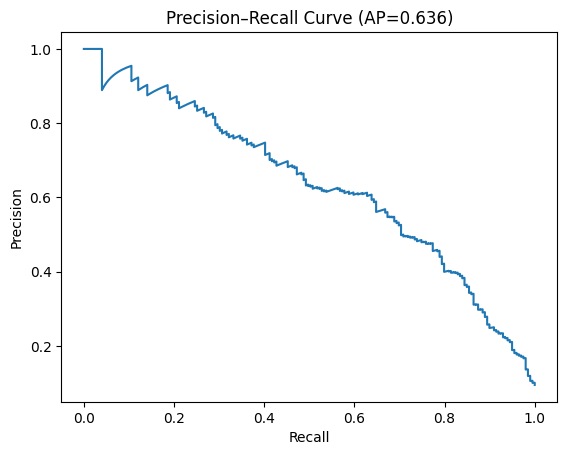

Chosen threshold: 0.28434625267982483


In [51]:
# =========================
# Stage 5 - Local Evaluation (Part D): Precision–Recall curve
# =========================

y_true_dev = analysis_df["y_true"].to_numpy()
y_prob_dev = analysis_df["y_prob"].to_numpy()

prec, rec, thr = precision_recall_curve(y_true_dev, y_prob_dev)
ap = average_precision_score(y_true_dev, y_prob_dev)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP={ap:.3f})")
plt.show()

print("Chosen threshold:", BEST_THR)

In [52]:
# =========================
# Stage 5 - Local Evaluation (Part E): Ablation on official dev
# =========================

display(ablation_df)

ablation_df.to_csv(os.path.join(RUN_DIR, "ablation_official_dev.csv"), index=False)
print("Saved ablation_official_dev.csv to:", RUN_DIR)

,run,thr,temp,pos_f1
3,bestlam_w1x05,0.284346,1.0,0.617284
0,lam025_w1x1,0.881746,1.0,0.601093
4,bestlam_w1x10,0.534312,1.0,0.596939
2,lam100_w1x1,0.820112,1.0,0.579634
1,lam050_w1x1,0.904556,1.0,0.568966


Saved ablation_official_dev.csv to: /content/drive/MyDrive/NLP_CW1_BestModel_final_fr/BestModel_Experiments/bestlam_w1x05


In [91]:
# =========================
# EDA PLOTS (Exercise 2)
# Generates the plots referenced by the report.
# =========================

DF = trdf1

def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

text_col = pick_col(["text", "paragraph", "par", "sentence"], DF.columns)
comm_col = pick_col(["community", "keyword", "kw"], DF.columns)
y_col    = pick_col(["label_bin", "label_binary", "label", "y"], DF.columns)

if text_col is None:
    raise ValueError(f"Could not find text column. Available columns: {list(DF.columns)}")
if comm_col is None:
    raise ValueError(f"Could not find community column. Available columns: {list(DF.columns)}")
if y_col is None:
    raise ValueError(f"Could not find binary label column. Available columns: {list(DF.columns)}")

y = DF[y_col].astype(int)
if not set(y.unique()).issubset({0, 1}):
    raise ValueError(f"Label column {y_col} is not binary 0/1. Unique values: {sorted(y.unique().tolist())}")

OUT_DIR = "."
os.makedirs(OUT_DIR, exist_ok=True)

# ---- Overall class distribution plot ----
counts = y.value_counts().sort_index()  # 0 then 1
plt.figure()
plt.bar(["No PCL (0)", "PCL (1)"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("Overall Class Distribution (Binary Labels)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "overall_class_distr_nlp.png"), dpi=200)
plt.close()

# ---- Community/keyword-level stats: counts + pos rate ----
comm_stats = (
    DF.assign(_y=y)
      .groupby(comm_col)["_y"]
      .agg(n="count", n_pos="sum")
      .reset_index()
)
comm_stats["n_neg"] = comm_stats["n"] - comm_stats["n_pos"]
comm_stats["pos_rate"] = comm_stats["n_pos"] / comm_stats["n"]

comm_stats_rate = comm_stats.sort_values("pos_rate", ascending=False).reset_index(drop=True)
comm_stats_n    = comm_stats.sort_values("n", ascending=False).reset_index(drop=True)

# ---- PCL positive rate by community/keyword ----
plt.figure(figsize=(10, 4))
plt.bar(comm_stats_rate[comm_col].astype(str), comm_stats_rate["pos_rate"].values)
plt.title("PCL Positive Rate by Community (Keyword)")
plt.ylabel("Positive rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pcl_pos_rate_by_keywrd_nlp.png"), dpi=200)
plt.close()

# ---- Number of examples by community/keyword ----
plt.figure(figsize=(10, 4))
plt.bar(comm_stats_n[comm_col].astype(str), comm_stats_n["n"].values)
plt.title("Number of Examples by Community (Keyword)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "num_ex_by_keywrd_nlp.png"), dpi=200)
plt.close()

# ---- Length features ----
# whitespace tokenisation
token_lens = DF[text_col].astype(str).apply(lambda s: len(s.split())).to_numpy()

# ---- Length histogram ----
plt.figure(figsize=(8, 4))
clip_max = np.percentile(token_lens, 99.5)
plt.hist(np.clip(token_lens, 0, clip_max), bins=50)
plt.title("Histogram of Token Counts (Whitespace Tokens)")
plt.xlabel("Token count (clipped at 99.5th percentile for display)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_histogram_nlp.png"), dpi=200)
plt.close()

# ---- Length boxplot by class ----
lens_0 = token_lens[y.to_numpy() == 0]
lens_1 = token_lens[y.to_numpy() == 1]

plt.figure(figsize=(6, 4))
plt.boxplot([lens_0, lens_1], labels=["No PCL (0)", "PCL (1)"], showfliers=False)
plt.title("Token Count Distribution by Class")
plt.ylabel("Token count (whitespace tokens)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_boxplot_nlp.png"), dpi=200)
plt.close()

print("Saved EDA plots to:", os.path.abspath(OUT_DIR))
print("Files:",
      "overall_class_distr_nlp.png, pcl_pos_rate_by_keywrd_nlp.png, num_ex_by_keywrd_nlp.png, "
      "length_histogram_nlp.png, length_boxplot_nlp.png")

Saved EDA plots to: /content/drive/MyDrive/NLP-cw-1-ki122
Files: overall_class_distr_nlp.png, pcl_pos_rate_by_keywrd_nlp.png, num_ex_by_keywrd_nlp.png, length_histogram_nlp.png, length_boxplot_nlp.png


/tmp/ipykernel_1056/1867565649.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lens_0, lens_1], labels=["No PCL (0)", "PCL (1)"], showfliers=False)


Sanity checks for threshold

In [54]:
# y_true, y_prob from internal val for selected ckpt/temp
y_true, y_prob = get_probs_and_labels(m, val_ds, device, temperature=BEST_TEMP)
y_pred = (y_prob >= BEST_THR).astype(int)

print("Val pos rate true :", y_true.mean())
print("Val pos rate pred :", y_pred.mean())
print("Threshold         :", BEST_THR)
print("Prob summary      :", np.min(y_prob), np.percentile(y_prob, [5,25,50,75,95]), np.max(y_prob))

Val pos rate true : 0.09466984884645982
Val pos rate pred : 0.10898965791567224
Threshold         : 0.28434625267982483
Prob summary      : 9.2432056e-05 [1.45023566e-04 2.25837342e-04 4.05374711e-04 2.17377185e-03
 9.47501755e-01] 0.99865013


In [55]:
from sklearn.metrics import f1_score

thr_grid = np.linspace(0.05, 0.95, 19)
f1s = []
for t in thr_grid:
    f1s.append(f1_score(y_true, (y_prob >= t).astype(int), pos_label=1, average="binary"))
for t, f in zip(thr_grid, f1s):
    print(f"{t:.2f}: {f:.4f}")

best_idx = int(np.argmax(f1s))
print("Best on grid:", thr_grid[best_idx], f1s[best_idx])

0.05: 0.5455
0.10: 0.5704
0.15: 0.5818
0.20: 0.6015
0.25: 0.6084
0.30: 0.6111
0.35: 0.6154
0.40: 0.6000
0.45: 0.6043
0.50: 0.5789
0.55: 0.5752
0.60: 0.5701
0.65: 0.5571
0.70: 0.5622
0.75: 0.5581
0.80: 0.5498
0.85: 0.5561
0.90: 0.5389
0.95: 0.4835
Best on grid: 0.35 0.6153846153846154
